## **Experiment 1: Baseline Transformer Training**

### **Goal**
Train a GPT-style Transformer model on a custom dataset and analyze training vs validation behavior.

### **Config Parameters**

### Model Architecture
* d_model = 128
* num_heads = 4
* num_layers = 4
* max_seq_len = 128         # for flexible sequence length

### Training Config
* batch_size = 16
* num_steps = 5000           # training iterations
* learning_rate = 3e-4
* grad_clip = 1.0            # safe: 0.5–1.0 (prevents exploding gradients)
* eval_iters = 100
* print_every = 200          # logging frequency
* seed = 42
* seq_len = 64

### Regularization
* embedding_dropout = 0.1       # used after emb+pos 
* attention_dropout = 0.2       # used inside MHA
* residual_dropout = 0.1        # used after MHA and FFN outputs

### Generation Config
* temperature = 1.0
* max_new_tokens = 20             # generated text length
* sampling_strategy = "top_p"     # or "top_k" or "greedy"
* top_p = 0.8
* top_k = 50

### explore
* weight_tying = False
* post_norm = False

### **Dataset information**
* random chunking
* train_samples: 36718
* val_samples: 3760
* test_samples: 4358

* train_tokens: 2391884
* val_tokens: 247289
* test_tokens: 283287
* vocab_size: 50257

## **Training Summary**

The model was trained for 40,000 steps with a batch size of 16 and sequence length of 64. Although the target was 100,000 steps, training was stopped early due to overfitting behavior observed in the validation metrics.

**Tokens processed so far:**  
40,000 steps × 16 batch size × 64 sequence length = **40,960,000 tokens** (41 million tokens)

### **Training Metrics overview (every 5,000 steps)**

| Step  | Train Loss | Train PPL | Val Loss | Val PPL |
|-------|------------|-----------|----------|---------|
| 5000  | 6.47       | 644       | 6.71     | 818     |
| 10000 | 5.85       | 348       | 6.15     | 467     |
| 15000 | 5.32       | 204       | 5.95     | 383     |
| 20000 | 4.99       | 146       | 5.88     | 357     |
| 25000 | 4.75       | 116       | 5.85     | 348     |
| 30000 | 4.57       | 97        | 5.85     | 346     |
| 35000 | 4.43       | 84        | 5.86     | 350     |
| 40000 | 4.31       | 74        | 5.87     | 355     |

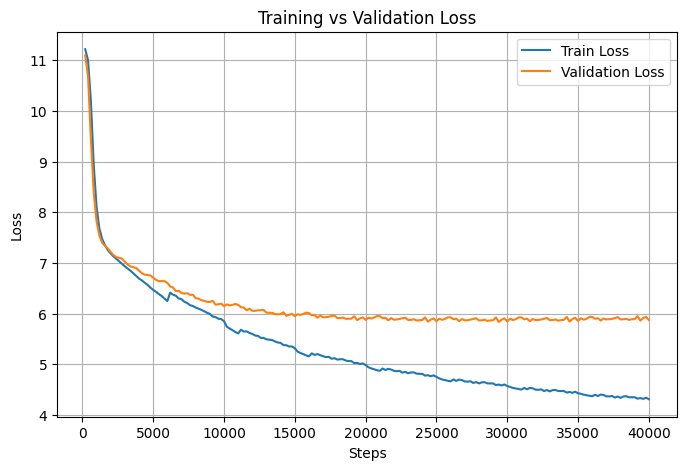

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV from checkpoints folder
file_path = r"..\checkpoints\exp1\training_metrics.csv"
df = pd.read_csv(file_path)

# Extract columns
steps = df["step"]
train_loss = df["train_loss"]
val_loss = df["val_loss"]

# Plot
plt.figure(figsize=(8, 5))  # wider graph
plt.plot(steps, train_loss, label="Train Loss")
plt.plot(steps, val_loss, label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig(r"..\checkpoints\exp1\loss_curve_exp1.png")
plt.show()

### **Observations**

### 1. Rapid Initial Learning
- Both training and validation loss drop sharply in early steps (~0–5K)
- Model quickly captures basic language structure

### 2. Stable Generalization Phase (5K → 20K)
- Train and validation loss decrease together
- Small gap between them

**Insight:** Model learns meaningful patterns, not just memorization

### 3. Validation Plateau (~20K Steps)
- Validation loss stabilizes around **5.85–5.9**
- No significant improvement beyond this point

**Insight:** Generalization limit reached under current configuration

### 4. Overfitting After 20K
- Training loss continues decreasing
- Validation loss stagnates or slightly worsens

**Insight:** Model begins memorizing training data

### 5. Increasing Train–Validation Gap
- Gap widens significantly after 20K steps

**Insight:** Model capacity exceeds effective dataset signal